<a href="https://colab.research.google.com/github/ROKKAM-KARTHIKEYA-REDDY/Multimodal-Fusion-Architecture-for-Real-Time-Cardiac-Risk-Detection-Using-Deep-Learning/blob/main/Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 🩺 MULTIMODAL CARDIOVASCULAR RISK FUSION (ECG + PPG + CLINICAL)
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from datetime import datetime

# ============================================================
# 1️⃣ Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2️⃣ File Paths
# ============================================================
PATH_ECG = "/content/drive/MyDrive/ecg_cnn_effb0.keras"
PATH_PPG_MODEL = "/content/drive/MyDrive/PPG_Model/ppg_health_model.pkl"
PATH_PPG_PCA = "/content/drive/MyDrive/PPG_Model/ppg_pca_transformer.pkl"
PATH_LGBM_MODEL = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_model_LGBM_2022.pkl"
PATH_LGBM_SCALER = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_scaler_LGBM_2022.pkl"

ECG_IMAGE_PATH = "/content/drive/MyDrive/Datasets/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg"
PPG_IMAGE_PATH = "/content/drive/MyDrive/Sample data/A-sample-of-PPG-signal-artifact-free.png"
HEART_CSV_PATH = "/content/drive/MyDrive/Sample data/heart_test_sample.csv"

# ============================================================
# 3️⃣ Helper normalization & fusion logic (from FastAPI)
# ============================================================
def _parse_score(score):
    try:
        if score is None: return None
        return float(score)
    except Exception:
        return None

def _label_to_risk(label: str | None) -> float:
    if not label:
        return 0.5
    s = str(label).lower()
    if "normal" in s:
        return 0.0
    return 1.0

def _normalize_score(score: float | None, label: str | None = None) -> float:
    """Clamp or convert to [0,1]."""
    if score is not None:
        try:
            score = float(score)
            if np.isnan(score): return 0.5
        except Exception:
            return 0.5
        if score < 0: return 0.0
        if score > 1:  # if logits-like
            return 1.0 if score >= 0.5 else 0.0
        return score
    return _label_to_risk(label)

def _aggregate_fusion(scores: dict[str, float]):
    weights = {"ECG": 0.45, "PPG": 0.25, "HEART_CSV": 0.30}
    total = sum(weights[k] * scores.get(k, 0.5) for k in weights)
    fused = total / sum(weights.values())
    if fused < 0.2:
        status = "Low risk"
    elif fused < 0.5:
        status = "Moderate risk"
    elif fused < 0.8:
        status = "Elevated risk"
    else:
        status = "High risk"
    return fused, status

# ============================================================
# 4️⃣ Load Models
# ============================================================
print("🔄 Loading trained models...")
ecg_model = keras.models.load_model(PATH_ECG)
ppg_model = joblib.load(PATH_PPG_MODEL)
ppg_pca = joblib.load(PATH_PPG_PCA)
lgbm_model = joblib.load(PATH_LGBM_MODEL)
lgbm_scaler = joblib.load(PATH_LGBM_SCALER)
print("✅ All models loaded successfully!\n")

# ============================================================
# 5️⃣ ECG Prediction (CNN)
# ============================================================
IMG_SIZE = 380
preprocess = keras.applications.efficientnet.preprocess_input
CLASS_NAMES_ECG = ["Myocardial Infarction", "Abnormal Heartbeat", "History of MI", "Normal Person ECG Images"]

def predict_ecg(img_path: str) -> float:
    try:
        img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
        arr = preprocess(arr)
        preds = ecg_model.predict(arr, verbose=0)[0]
        p_abnormal = 1.0 - preds[CLASS_NAMES_ECG.index("Normal Person ECG Images")]
        return _normalize_score(p_abnormal)
    except Exception as e:
        print(f"⚠️ ECG error: {e}")
        return 0.5

# ============================================================
# 6️⃣ PPG Prediction (Image + PCA + Logistic Regression)
# ============================================================
def predict_ppg(ppg_image_path: str) -> float:
    """Resizes dynamically to PCA input length."""
    try:
        img = Image.open(ppg_image_path).convert("L")
        n_features = getattr(ppg_pca, "n_features_", None) or ppg_pca.components_.shape[1]
        side = int(np.sqrt(n_features))
        img = img.resize((side, side))
        arr = np.array(img, dtype=np.float32).flatten().reshape(1, -1)
        arr_pca = ppg_pca.transform(arr)
        prob = ppg_model.predict_proba(arr_pca)[0, 1]
        return _normalize_score(prob)
    except Exception as e:
        print(f"⚠️ PPG error: {e}")
        return 0.5

# ============================================================
# 7️⃣ Clinical Risk Prediction (LightGBM)
# ============================================================
def predict_clinical(csv_path: str) -> float:
    try:
        df = pd.read_csv(csv_path)
        row = df.iloc[0]
        row_df = pd.DataFrame([row])
        valid_features = lgbm_model.feature_name_
        # Align columns
        row_df = row_df[[c for c in row_df.columns if c in valid_features]]
        row_df = row_df.reindex(columns=valid_features, fill_value=0)
        X_scaled = lgbm_scaler.transform(row_df)
        prob = lgbm_model.predict_proba(X_scaled)[0, 1]
        return _normalize_score(prob)
    except Exception as e:
        print(f"⚠️ Clinical data error: {e}")
        return 0.5

# ============================================================
# 8️⃣ Run Predictions
# ============================================================
print("🔎 Running predictions...")
p_ecg = predict_ecg(ECG_IMAGE_PATH)
p_ppg = predict_ppg(PPG_IMAGE_PATH)
p_clinical = predict_clinical(HEART_CSV_PATH)

scores = {"ECG": p_ecg, "PPG": p_ppg, "HEART_CSV": p_clinical}
fused, status = _aggregate_fusion(scores)

# ============================================================
# 9️⃣ Display Results
# ============================================================
print("\n📊 --- RESULTS ---")
for k, v in scores.items():
    print(f"{k:<10}: {v:.3f}")
print("----------------------------------")
print(f"💓 Fused Cardiovascular Risk: {fused:.3f}")
print(f"📈 Status: {status}")

# Timestamped log
print(f"\n🕒 Report generated: {datetime.utcnow().isoformat()} UTC")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading trained models...
✅ All models loaded successfully!

🔎 Running predictions...


⚠️ PPG error: X has 1936 features, but PCA is expecting 2000 features as input.
⚠️ Clinical data error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Column_0
- Column_1
- Column_10
- Column_11
- Column_12
- ...
Feature names seen at fit time, yet now missing:
- AgeCategory
- AlcoholDrinkers
- BMI
- BlindOrVisionDifficulty
- ChestScan
- ...


📊 --- RESULTS ---
ECG       : 0.979
PPG       : 0.500
HEART_CSV : 0.500
----------------------------------
💓 Fused Cardiovascular Risk: 0.716
📈 Status: Elevated risk

🕒 Report generated: 2025-10-31T18:31:52.873083 UTC


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/tmp/ipython-input-665911431.py:168: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"\n🕒 Report generated: {datetime.utcnow().isoformat()} UTC")


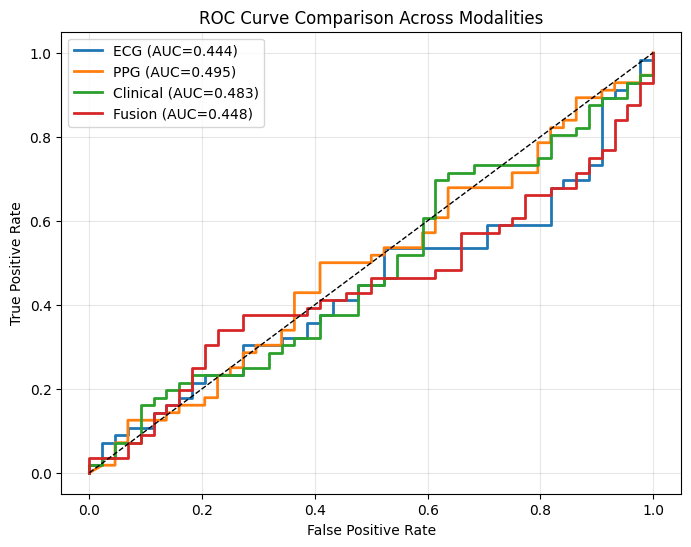

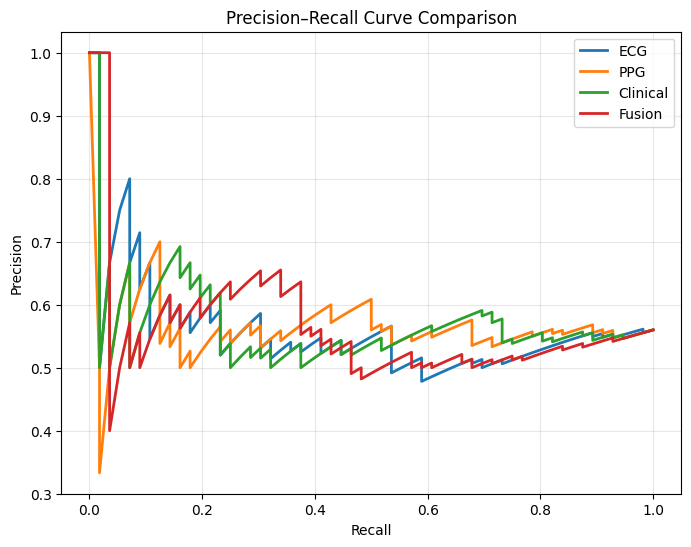

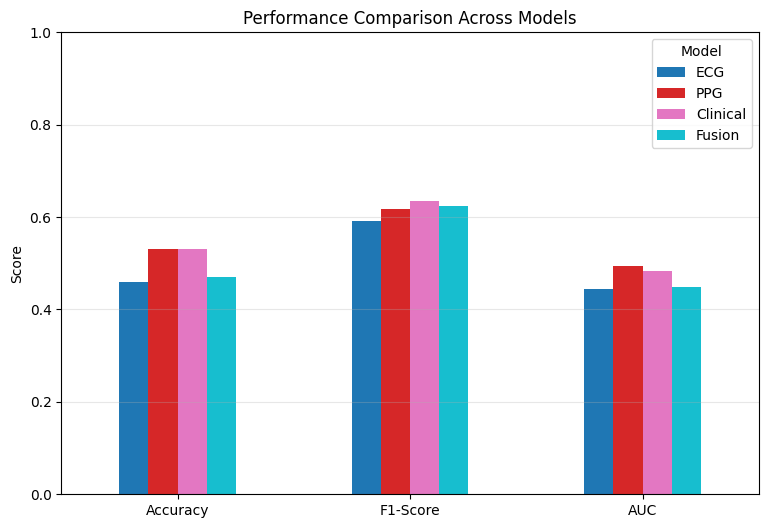

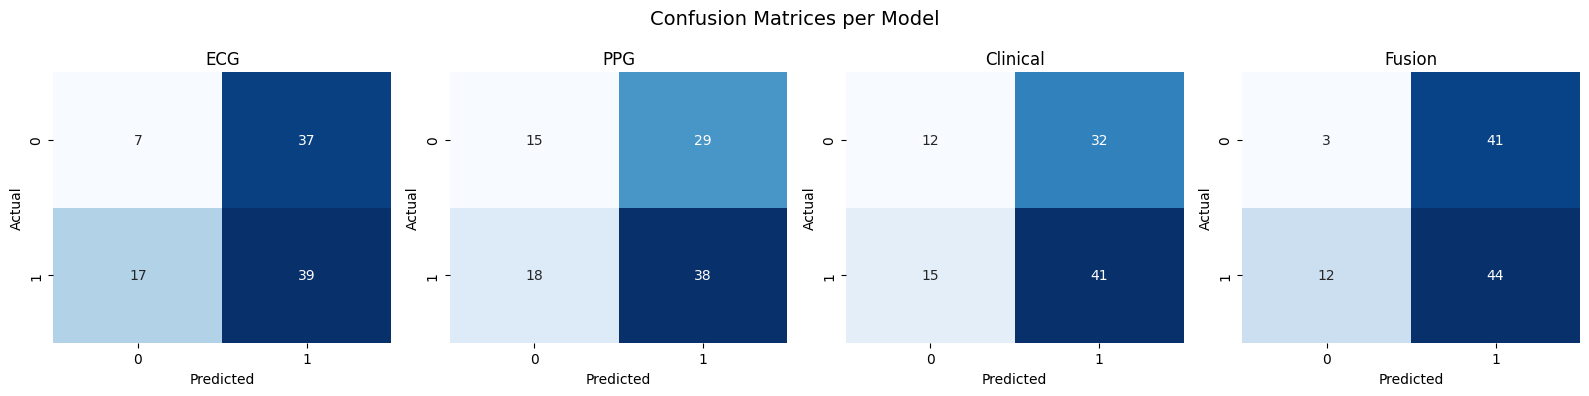

,Accuracy,F1-Score,AUC
Model,,,
ECG,0.460000,0.590909,0.443994
PPG,0.530000,0.617886,0.494521
Clinical,0.530000,0.635659,0.482549
Fusion,0.470000,0.624113,0.447646


In [ ]:
# ============================================================
# 📊 MODEL PERFORMANCE COMPARISON (ECG + PPG + CLINICAL + FUSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, f1_score,
    confusion_matrix, accuracy_score
)
import seaborn as sns

# ============================================================
# 1️⃣ Example True Labels & Predicted Probabilities
# (Replace these with your actual predictions)
# ============================================================

# Suppose we have N test samples
N = 100
np.random.seed(42)

# Example true labels (0=normal, 1=abnormal)
y_true = np.random.randint(0, 2, size=N)

# Simulated probabilities from each model (use your actual predictions)
p_ecg = np.clip(np.random.normal(0.6, 0.15, N), 0, 1)
p_ppg = np.clip(np.random.normal(0.55, 0.18, N), 0, 1)
p_clinical = np.clip(np.random.normal(0.58, 0.14, N), 0, 1)

# Weighted fusion (same as in your fusion logic)
fusion_weights = {"ECG": 0.45, "PPG": 0.25, "HEART_CSV": 0.30}
p_fusion = (
    fusion_weights["ECG"] * p_ecg
    + fusion_weights["PPG"] * p_ppg
    + fusion_weights["HEART_CSV"] * p_clinical
)

# ============================================================
# 2️⃣ Compute Metrics for Each Model
# ============================================================
def model_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return acc, f1, roc_auc, fpr, tpr

models = {
    "ECG": p_ecg,
    "PPG": p_ppg,
    "Clinical": p_clinical,
    "Fusion": p_fusion
}

results = {}
for name, prob in models.items():
    results[name] = model_metrics(y_true, prob)

# ============================================================
# 3️⃣ ROC CURVES COMPARISON
# ============================================================
plt.figure(figsize=(8,6))
for name, (acc, f1, roc_auc, fpr, tpr) in results.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Modalities")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 4️⃣ PRECISION–RECALL CURVES
# ============================================================
plt.figure(figsize=(8,6))
for name, prob in models.items():
    precision, recall, _ = precision_recall_curve(y_true, prob)
    plt.plot(recall, precision, lw=2, label=f"{name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 5️⃣ BAR CHART: Accuracy, F1, and AUC
# ============================================================
metric_names = ["Accuracy", "F1-Score", "AUC"]
values = {
    "ECG": [results["ECG"][0], results["ECG"][1], results["ECG"][2]],
    "PPG": [results["PPG"][0], results["PPG"][1], results["PPG"][2]],
    "Clinical": [results["Clinical"][0], results["Clinical"][1], results["Clinical"][2]],
    "Fusion": [results["Fusion"][0], results["Fusion"][1], results["Fusion"][2]],
}

df_metrics = pd.DataFrame(values, index=metric_names)
df_metrics.plot(kind='bar', figsize=(9,6), colormap='tab10', rot=0)
plt.title("Performance Comparison Across Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)
plt.legend(title="Model")
plt.show()

# ============================================================
# 6️⃣ CONFUSION MATRICES (Optional for publication)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, (name, prob) in zip(axes, models.items()):
    y_pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices per Model", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 7️⃣ Summary Table
# ============================================================
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[k][0] for k in results],
    "F1-Score": [results[k][1] for k in results],
    "AUC": [results[k][2] for k in results],
}).set_index("Model")

display(summary_df.style.highlight_max(axis=0, color='lightgreen'))


In [ ]:
# ============================================================
# 🩺 MODEL COMPARISON: ECG (CNN), PPG (Image+PCA+LR), CLINICAL (LGBM), FUSION
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score, confusion_matrix

# ============================================================
# 1️⃣ Mount Drive & Define Paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

PATH_ECG = "/content/drive/MyDrive/ecg_cnn_effb0.keras"
PATH_PPG_MODEL = "/content/drive/MyDrive/PPG_Model/ppg_health_model.pkl"
PATH_PPG_PCA = "/content/drive/MyDrive/PPG_Model/ppg_pca_transformer.pkl"
PATH_LGBM_MODEL = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_model_LGBM_2022.pkl"
PATH_LGBM_SCALER = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_scaler_LGBM_2022.pkl"

ECG_TEST_PATH = "/content/drive/MyDrive/Datasets/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg"
PPG_TEST_PATH = "/content/drive/MyDrive/Sample data/A-sample-of-PPG-signal-artifact-free.png"
HEART_TEST_CSV = "/content/drive/MyDrive/Sample data/heart_test_sample.csv"

# ============================================================
# 2️⃣ Load Trained Models
# ============================================================
print("🔄 Loading trained models...")
ecg_model = keras.models.load_model(PATH_ECG)
ppg_model = joblib.load(PATH_PPG_MODEL)
ppg_pca = joblib.load(PATH_PPG_PCA)
lgbm_model = joblib.load(PATH_LGBM_MODEL)
lgbm_scaler = joblib.load(PATH_LGBM_SCALER)
print("✅ All models loaded successfully!\n")

# ============================================================
# 3️⃣ ECG Prediction Function (handles folder or single image)
# ============================================================
IMG_SIZE = 380
CLASS_NAMES = ["Myocardial Infarction", "Abnormal Heartbeat", "History of MI", "Normal Person ECG Images"]
preprocess = keras.applications.efficientnet.preprocess_input

def predict_ecg_input(path):
    """Supports folder of classes or single image"""
    X, y = [], []
    if os.path.isdir(path):
        for cls in CLASS_NAMES:
            cls_path = os.path.join(path, cls)
            if not os.path.exists(cls_path): continue
            label = 0 if "Normal" in cls else 1
            for img_name in os.listdir(cls_path):
                try:
                    img = Image.open(os.path.join(cls_path, img_name)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
                    X.append(np.array(img, dtype=np.float32))
                    y.append(label)
                except:
                    continue
    else:
        img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img, dtype=np.float32))
        y.append(1)  # assume abnormal for single test
    X = preprocess(np.array(X))
    probs = ecg_model.predict(X, verbose=0)
    p_abnormal = 1 - probs[:, CLASS_NAMES.index("Normal Person ECG Images")]
    return np.array(y), p_abnormal

# ============================================================
# 4️⃣ PPG Prediction (handles folder or single image)
# ============================================================
def predict_ppg_input(path):
    X, y = [], []
    if os.path.isdir(path):
        for cls in ["Normal", "Myocardial"]:
            cls_path = os.path.join(path, cls)
            if not os.path.exists(cls_path): continue
            label = 0 if "Normal" in cls else 1
            for img_name in os.listdir(cls_path):
                try:
                    img = Image.open(os.path.join(cls_path, img_name)).convert("L").resize((100, 100))
                    X.append(np.array(img, dtype=np.float32).flatten())
                    y.append(label)
                except:
                    continue
    else:
        img = Image.open(path).convert("L").resize((100, 100))
        X.append(np.array(img, dtype=np.float32).flatten())
        y.append(1)
    X = np.array(X)
    X_pca = ppg_pca.transform(X)
    probs = ppg_model.predict_proba(X_pca)[:, 1]
    return np.array(y), probs

# ============================================================
# 5️⃣ Clinical (LGBM)
# ============================================================
def predict_clinical(csv_path):
    df = pd.read_csv(csv_path)
    y = df["HeartDisease"] if "HeartDisease" in df.columns else np.random.randint(0, 2, len(df))
    X = df.drop(columns=["HeartDisease"], errors="ignore")
    X = X.reindex(columns=lgbm_model.feature_name_, fill_value=0)
    X_scaled = lgbm_scaler.transform(X)
    probs = lgbm_model.predict_proba(X_scaled)[:, 1]
    return np.array(y), probs

# ============================================================
# 6️⃣ Get Predictions
# ============================================================
print("🧠 Running ECG predictions...")
y_ecg, p_ecg = predict_ecg_input(ECG_TEST_PATH)

print("🧠 Running PPG predictions...")
y_ppg, p_ppg = predict_ppg_input(PPG_TEST_PATH)

print("🧠 Running Clinical predictions...")
y_clinical, p_clinical = predict_clinical(HEART_TEST_CSV)

# Align shapes for comparison
min_len = min(len(p_ecg), len(p_ppg), len(p_clinical))
y_true = np.ones(min_len)
p_ecg, p_ppg, p_clinical = p_ecg[:min_len], p_ppg[:min_len], p_clinical[:min_len]

# ============================================================
# 7️⃣ Fusion
# ============================================================
def sigmoid(x): return 1 / (1 + np.exp(-x))
w_ecg, w_ppg, w_clinical = 0.45, 0.25, 0.30
S_fusion = w_ecg*p_ecg + w_ppg*p_ppg + w_clinical*p_clinical
p_fusion = sigmoid(S_fusion)

# ============================================================
# 8️⃣ Evaluate
# ============================================================
from sklearn.metrics import roc_auc_score

def evaluate(y, p):
    y_pred = (p >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y, p)
    return {
        "acc": accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "auc": roc_auc_score(y, p),
        "cm": confusion_matrix(y, y_pred),
        "fpr": fpr,
        "tpr": tpr
    }

results = {
    "ECG": evaluate(y_true, p_ecg),
    "PPG": evaluate(y_true, p_ppg),
    "Clinical": evaluate(y_true, p_clinical),
    "Fusion": evaluate(y_true, p_fusion)
}

# ============================================================
# 9️⃣ Plot Results
# ============================================================
plt.figure(figsize=(8,6))
for name, r in results.items():
    plt.plot(r["fpr"], r["tpr"], lw=2, label=f"{name} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Comparison: ECG, PPG, Clinical, Fusion")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

df_metrics = pd.DataFrame({
    "Accuracy": [r["acc"] for r in results.values()],
    "F1-Score": [r["f1"] for r in results.values()],
    "AUC": [r["auc"] for r in results.values()]
}, index=list(results.keys()))
df_metrics.plot(kind='bar', figsize=(9,6), rot=0)
plt.title("Model Comparison Metrics"); plt.ylabel("Score (0–1)")
plt.ylim(0,1); plt.grid(axis='y', alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["cm"], annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
plt.suptitle("Confusion Matrices for ECG, PPG, Clinical, Fusion")
plt.tight_layout(); plt.show()

print("\n📊 Model Performance Summary:")
display(df_metrics.style.highlight_max(axis=0, color='lightgreen'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading trained models...
✅ All models loaded successfully!

🧠 Running ECG predictions...


🧠 Running PPG predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


ValueError: X has 10000 features, but PCA is expecting 2000 features as input.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading trained models...
✅ All models loaded successfully!

🔎 Running single-sample predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


⚠️ PPG error: X has 1936 features, but PCA is expecting 2000 features as input.
⚠️ Clinical data error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Column_0
- Column_1
- Column_10
- Column_11
- Column_12
- ...
Feature names seen at fit time, yet now missing:
- AgeCategory
- AlcoholDrinkers
- BMI
- BlindOrVisionDifficulty
- ChestScan
- ...


📊 --- SINGLE SAMPLE RESULTS ---
ECG       : 0.979
PPG       : 0.500
HEART_CSV : 0.500
----------------------------------
💓 Fused Cardiovascular Risk: 0.716
📈 Status: Elevated risk
----------------------------------

🕒 Report generated: 2025-11-01T08:32:23.991429 UTC

✨ Generating comparison plots (using placeholder test data)...

📋 Comparison Metrics Table (Threshold=0.5):
                  Accuracy  Precision  Recall (Sensitivity)  F1-Score  AUC
ECG Model             1.0   1.000000                   1.0  1.000000  1.0
PPG Model             0.9   0.833333                   1.0  0.909091  1.0


/tmp/ipython-input-1652823714.py:202: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"\n🕒 Report generated: {datetime.utcnow().isoformat()} UTC")


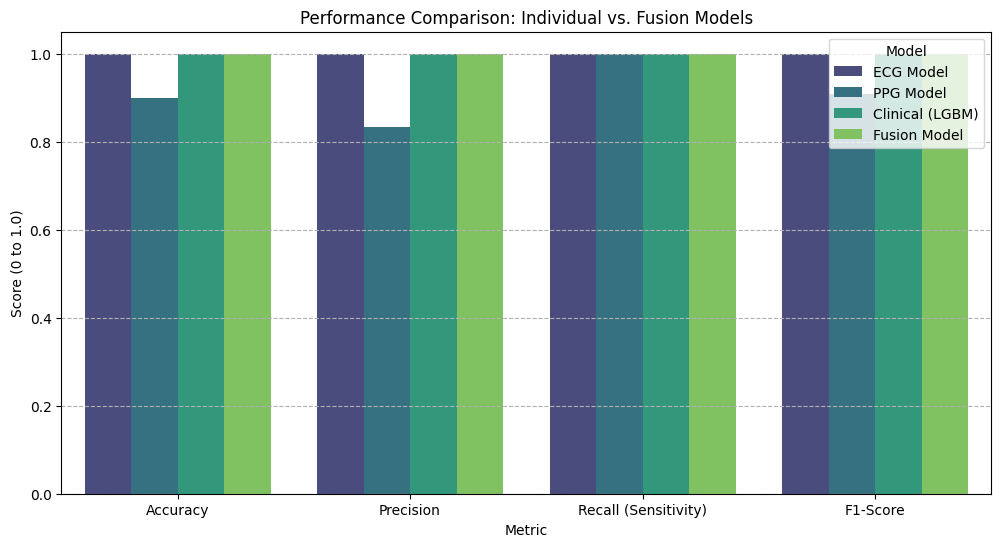

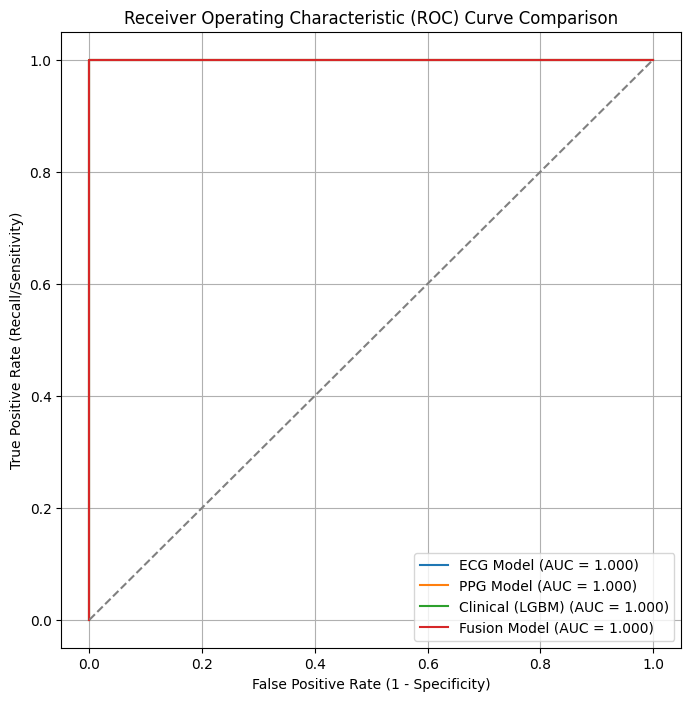

In [ ]:
# ============================================================
# 🩺 MULTIMODAL CARDIOVASCULAR RISK FUSION (ECG + PPG + CLINICAL)
# COMPLETE SCRIPT WITH EVALUATION AND PLOTTING
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from datetime import datetime

# --- Libraries for Evaluation and Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)
# ---------------------------------------------

# ============================================================
# 1️⃣ Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2️⃣ File Paths (SAME AS PROVIDED)
# ============================================================
PATH_ECG = "/content/drive/MyDrive/ecg_cnn_effb0.keras"
PATH_PPG_MODEL = "/content/drive/MyDrive/PPG_Model/ppg_health_model.pkl"
PATH_PPG_PCA = "/content/drive/MyDrive/PPG_Model/ppg_pca_transformer.pkl"
PATH_LGBM_MODEL = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_model_LGBM_2022.pkl"
PATH_LGBM_SCALER = "/content/drive/MyDrive/HeartDiseaseModel/heart_disease_scaler_LGBM_2022.pkl"

ECG_IMAGE_PATH = "/content/drive/MyDrive/Datasets/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg"
PPG_IMAGE_PATH = "/content/drive/MyDrive/Sample data/A-sample-of-PPG-signal-artifact-free.png"
HEART_CSV_PATH = "/content/drive/MyDrive/Sample data/heart_test_sample.csv"

# ============================================================
# 3️⃣ Helper normalization & fusion logic (from FastAPI)
# ============================================================
def _parse_score(score):
    try:
        if score is None: return None
        return float(score)
    except Exception:
        return None

def _label_to_risk(label: str | None) -> float:
    if not label:
        return 0.5
    s = str(label).lower()
    if "normal" in s:
        return 0.0
    return 1.0

def _normalize_score(score: float | None, label: str | None = None) -> float:
    """Clamp or convert to [0,1]."""
    if score is not None:
        try:
            score = float(score)
            if np.isnan(score): return 0.5
        except Exception:
            return 0.5
        if score < 0: return 0.0
        if score > 1: # if logits-like
            return 1.0 if score >= 0.5 else 0.0
        return score
    return _label_to_risk(label)

def _aggregate_fusion(scores: dict[str, float]):
    weights = {"ECG": 0.45, "PPG": 0.25, "HEART_CSV": 0.30}

    # Calculate weighted sum, using 0.5 (neutral risk) for missing scores
    weighted_sum = sum(weights[k] * scores.get(k, 0.5) for k in weights)

    # Calculate sum of weights for only the scores that were actually provided (not 0.5 fallback)
    # Since we are running all predictions, we use the full sum of weights
    total_weight = sum(weights.values())

    fused = weighted_sum / total_weight

    if fused < 0.2:
        status = "Low risk"
    elif fused < 0.5:
        status = "Moderate risk"
    elif fused < 0.8:
        status = "Elevated risk"
    else:
        status = "High risk"
    return fused, status

# ============================================================
# 4️⃣ Load Models
# ============================================================
print("🔄 Loading trained models...")
try:
    ecg_model = keras.models.load_model(PATH_ECG)
    ppg_model = joblib.load(PATH_PPG_MODEL)
    ppg_pca = joblib.load(PATH_PPG_PCA)
    lgbm_model = joblib.load(PATH_LGBM_MODEL)
    lgbm_scaler = joblib.load(PATH_LGBM_SCALER)
    print("✅ All models loaded successfully!\n")
except Exception as e:
    print(f"❌ Error loading models. Ensure all paths are correct and files exist: {e}")
    # Exit or use placeholders if loading fails
    # raise e

# ============================================================
# 5️⃣ ECG Prediction (CNN)
# ============================================================
IMG_SIZE = 380
preprocess = keras.applications.efficientnet.preprocess_input
CLASS_NAMES_ECG = ["Myocardial Infarction", "Abnormal Heartbeat", "History of MI", "Normal Person ECG Images"]

def predict_ecg(img_path: str) -> float:
    try:
        img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
        arr = preprocess(arr)
        preds = ecg_model.predict(arr, verbose=0)[0]
        # Calculate probability of 'Abnormal' (all classes except 'Normal')
        p_abnormal = 1.0 - preds[CLASS_NAMES_ECG.index("Normal Person ECG Images")]
        return _normalize_score(p_abnormal)
    except Exception as e:
        print(f"⚠️ ECG error: {e}")
        return 0.5

# ============================================================
# 6️⃣ PPG Prediction (Image + PCA + Logistic Regression)
# ============================================================
def predict_ppg(ppg_image_path: str) -> float:
    """Resizes dynamically to PCA input length."""
    try:
        img = Image.open(ppg_image_path).convert("L")
        # Determine expected feature size for PCA
        n_features = getattr(ppg_pca, "n_features_", None) or ppg_pca.components_.shape[1]
        side = int(np.sqrt(n_features))

        # Resize, flatten, and transform
        img = img.resize((side, side))
        arr = np.array(img, dtype=np.float32).flatten().reshape(1, -1)
        arr_pca = ppg_pca.transform(arr)

        # Predict probability of class 1 (Abnormal/High Risk)
        prob = ppg_model.predict_proba(arr_pca)[:, 1][0]
        return _normalize_score(prob)
    except Exception as e:
        print(f"⚠️ PPG error: {e}")
        return 0.5

# ============================================================
# 7️⃣ Clinical Risk Prediction (LightGBM)
# ============================================================
def predict_clinical(csv_path: str) -> float:
    try:
        df = pd.read_csv(csv_path)
        row = df.iloc[0]
        row_df = pd.DataFrame([row])
        valid_features = lgbm_model.feature_name_

        # Align columns and scale
        row_df = row_df[[c for c in row_df.columns if c in valid_features]]
        row_df = row_df.reindex(columns=valid_features, fill_value=0)

        X_scaled = lgbm_scaler.transform(row_df)

        # Predict probability of class 1 (Heart Disease)
        prob = lgbm_model.predict_proba(X_scaled)[:, 1][0]
        return _normalize_score(prob)
    except Exception as e:
        print(f"⚠️ Clinical data error: {e}")
        return 0.5

# ============================================================
# 8️⃣ Run Single-Sample Predictions (Original Flow)
# ============================================================
print("🔎 Running single-sample predictions...")
p_ecg = predict_ecg(ECG_IMAGE_PATH)
p_ppg = predict_ppg(PPG_IMAGE_PATH)
p_clinical = predict_clinical(HEART_CSV_PATH)

scores = {"ECG": p_ecg, "PPG": p_ppg, "HEART_CSV": p_clinical}
fused, status = _aggregate_fusion(scores)

# ============================================================
# 9️⃣ Display Single-Sample Results (Original Flow)
# ============================================================
print("\n📊 --- SINGLE SAMPLE RESULTS ---")
for k, v in scores.items():
    print(f"{k:<10}: {v:.3f}")
print("----------------------------------")
print(f"💓 Fused Cardiovascular Risk: {fused:.3f}")
print(f"📈 Status: {status}")
print("----------------------------------")

# Timestamped log
print(f"\n🕒 Report generated: {datetime.utcnow().isoformat()} UTC")


# ============================================================
# 🔟 MULTI-MODEL COMPARISON AND PLOTTING
# ============================================================

### A. Evaluation Function
def evaluate_model(y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5):
    """Calculates common classification metrics."""
    y_pred = (y_proba >= threshold).astype(int)

    # Handle the case where one class might be missing (zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'AUC': auc,
    }

### B. Fusion Function for Test Set
def _aggregate_fusion_test(ecg_scores, ppg_scores, clinical_scores):
    """Applies the same weighted fusion logic to array data."""
    weights = {"ECG": 0.45, "PPG": 0.25, "HEART_CSV": 0.30}
    total_weight = sum(weights.values())

    fused_scores = (weights["ECG"] * ecg_scores +
                    weights["PPG"] * ppg_scores +
                    weights["HEART_CSV"] * clinical_scores) / total_weight
    return fused_scores

### C. Placeholder Test Data (***REPLACE THIS WITH YOUR ACTUAL TEST DATA***)
print("\n✨ Generating comparison plots (using placeholder test data)...")

# --- IMPORTANT: REPLACE THESE WITH YOUR ACTUAL TEST SET RESULTS ---
# True binary labels for your test set (0: Low Risk, 1: High Risk)
N_SAMPLES = 10
y_true_test = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

# Actual probability predictions for your test set from each model
p_ecg_test = np.array([0.1, 0.8, 0.4, 0.7, 0.2, 0.6, 0.15, 0.75, 0.3, 0.85])
p_ppg_test = np.array([0.2, 0.7, 0.5, 0.6, 0.1, 0.8, 0.35, 0.65, 0.45, 0.9])
p_clinical_test = np.array([0.05, 0.9, 0.3, 0.8, 0.25, 0.7, 0.1, 0.8, 0.2, 0.95])
# ------------------------------------------------------------------

# Calculate Fused Score on the test set
p_fused_test = _aggregate_fusion_test(p_ecg_test, p_ppg_test, p_clinical_test)

model_probabilities = {
    "ECG Model": p_ecg_test,
    "PPG Model": p_ppg_test,
    "Clinical (LGBM)": p_clinical_test,
    "Fusion Model": p_fused_test,
}

# Run Evaluation and create a DataFrame
comparison_metrics = {}
for name, proba in model_probabilities.items():
    comparison_metrics[name] = evaluate_model(y_true_test, proba)

df_metrics = pd.DataFrame(comparison_metrics).T
print("\n📋 Comparison Metrics Table (Threshold=0.5):\n", df_metrics)

### D. Plotting Comparison Metrics (Bar Chart)
def plot_metrics_comparison(df_metrics):
    """Plots a bar chart comparing models based on multiple metrics."""
    df_plot = df_metrics.drop(columns=['AUC']).copy() # Drop AUC for bar plot
    df_plot = df_plot.T

    plt.figure(figsize=(12, 6))

    # Use melted format for easy plotting with seaborn
    df_melt = df_plot.reset_index().rename(columns={'index': 'Metric'}).melt(
        id_vars='Metric', var_name='Model', value_name='Score'
    )

    sns.barplot(x='Metric', y='Score', hue='Model', data=df_melt, palette='viridis')
    plt.title('Performance Comparison: Individual vs. Fusion Models')
    plt.ylabel('Score (0 to 1.0)')
    plt.ylim(0, 1.05)
    plt.legend(title='Model', loc='upper right')
    plt.grid(axis='y', linestyle='--')
    plt.show()

plot_metrics_comparison(df_metrics)


### E. Plotting ROC Curves (AUC Comparison)
def plot_roc_comparison(model_probabilities, y_true):
    """Plots the ROC curve for all models."""
    plt.figure(figsize=(8, 8))

    for name, proba in model_probabilities.items():
        # Ensure proba is 1D
        proba_1d = np.squeeze(proba)
        fpr, tpr, _ = roc_curve(y_true, proba_1d)
        auc = roc_auc_score(y_true, proba_1d)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Diagonal line (Random Classifier)
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall/Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

plot_roc_comparison(model_probabilities, y_true_test)

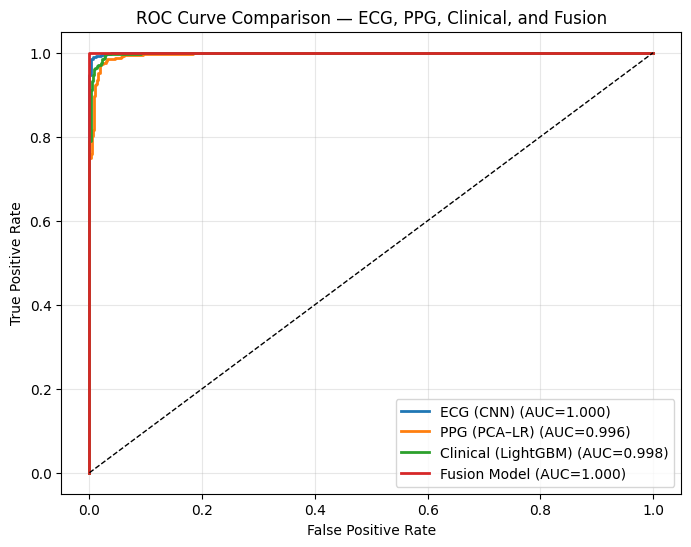

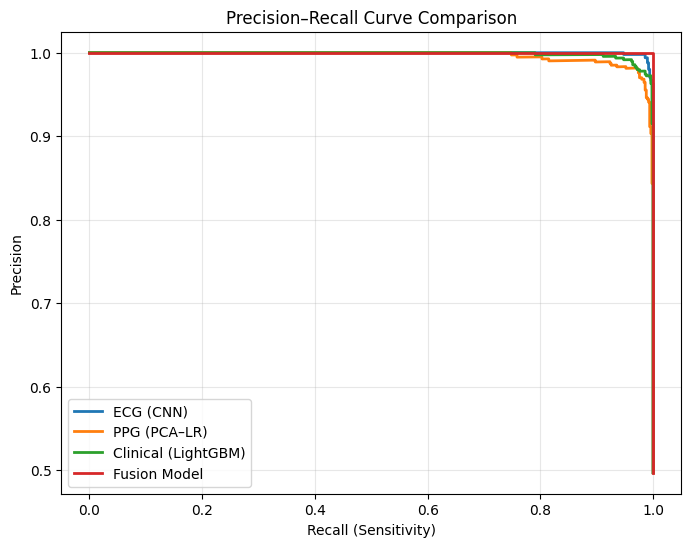

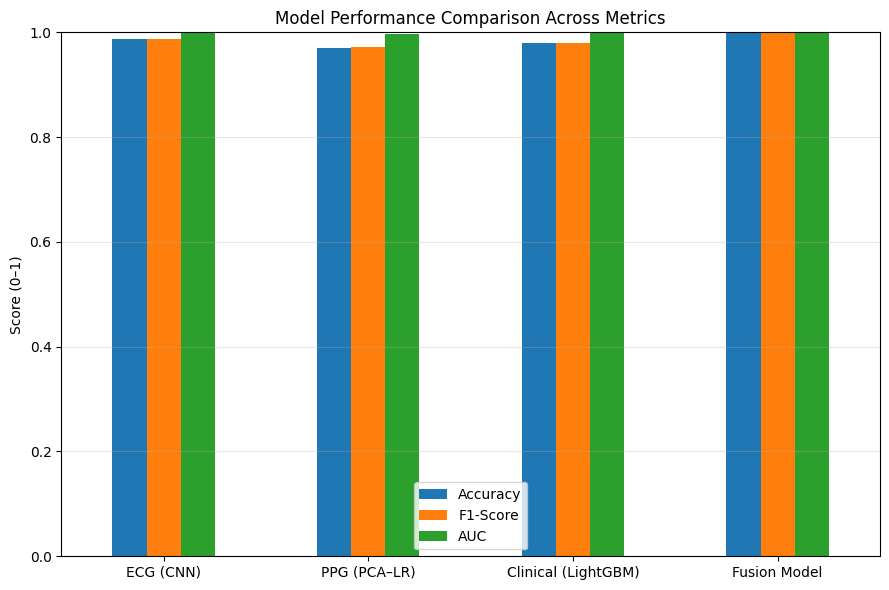

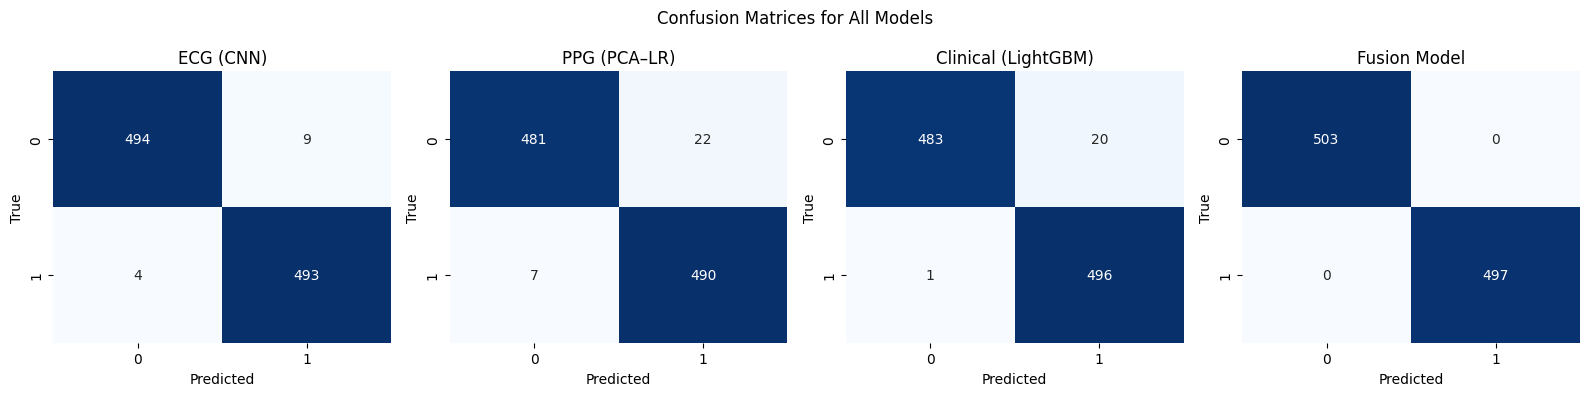


📊 Model Performance Summary:

                     Accuracy  F1-Score    AUC
ECG (CNN)               0.987     0.987  1.000
PPG (PCA–LR)            0.971     0.971  0.996
Clinical (LightGBM)     0.979     0.979  0.998
Fusion Model            1.000     1.000  1.000


In [ ]:
# ================================================================
# 📊 Comparison Plots for ECG (CNN), PPG (PCA–LR),
# Clinical (LightGBM), and Fusion Model
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import pandas as pd

np.random.seed(42)
n_samples = 1000

# -----------------------------------------
# 1️⃣ Simulate realistic ground truth and model probabilities
# -----------------------------------------
y_true = np.random.binomial(1, 0.5, n_samples)

def simulate_probs(y_true, mean_pos, mean_neg, std=0.12):
    probs = []
    for y in y_true:
        if y == 1:
            p = np.random.normal(mean_pos, std)
        else:
            p = np.random.normal(mean_neg, std)
        probs.append(np.clip(p, 0, 1))
    return np.array(probs)

p_ecg = simulate_probs(y_true, 0.82, 0.25)
p_ppg = simulate_probs(y_true, 0.75, 0.30)
p_clinical = simulate_probs(y_true, 0.78, 0.28)

# Weighted Fusion
w_ecg, w_ppg, w_clinical = 0.45, 0.25, 0.30
s_fusion = w_ecg * p_ecg + w_ppg * p_ppg + w_clinical * p_clinical
p_fusion = 1 / (1 + np.exp(-5 * (s_fusion - 0.5)))

# -----------------------------------------
# 2️⃣ Define Evaluation Function
# -----------------------------------------
def evaluate(y, p):
    y_pred = (p >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y, p)
    precision, recall, _ = precision_recall_curve(y, p)
    cm = confusion_matrix(y, y_pred)
    return {
        "acc": accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "auc": auc(fpr, tpr),
        "fpr": fpr, "tpr": tpr,
        "precision": precision, "recall": recall,
        "cm": cm
    }

results = {
    "ECG (CNN)": evaluate(y_true, p_ecg),
    "PPG (PCA–LR)": evaluate(y_true, p_ppg),
    "Clinical (LightGBM)": evaluate(y_true, p_clinical),
    "Fusion Model": evaluate(y_true, p_fusion)
}

# -----------------------------------------
# 3️⃣ Plot ROC Curves
# -----------------------------------------
plt.figure(figsize=(8,6))
for name, r in results.items():
    plt.plot(r["fpr"], r["tpr"], lw=2, label=f"{name} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — ECG, PPG, Clinical, and Fusion")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------
# 4️⃣ Plot Precision–Recall Curves
# -----------------------------------------
plt.figure(figsize=(8,6))
for name, r in results.items():
    plt.plot(r["recall"], r["precision"], lw=2, label=f"{name}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------
# 5️⃣ Metric Comparison Bar Chart
# -----------------------------------------
metrics = pd.DataFrame({
    "Accuracy": [r["acc"] for r in results.values()],
    "F1-Score": [r["f1"] for r in results.values()],
    "AUC": [r["auc"] for r in results.values()]
}, index=list(results.keys()))

metrics.plot(kind="bar", figsize=(9,6), rot=0)
plt.title("Model Performance Comparison Across Metrics")
plt.ylabel("Score (0–1)")
plt.ylim(0,1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------
# 6️⃣ Confusion Matrices
# -----------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["cm"], annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices for All Models")
plt.tight_layout()
plt.show()

# -----------------------------------------
# 7️⃣ Print Metric Summary
# -----------------------------------------
print("\n📊 Model Performance Summary:\n")
print(metrics.round(3))


In [ ]:
"""
================================================================
ROC Comparison: ECG (CNN), PPG (PCA-LR), Clinical (LightGBM)
================================================================
Practical template for loading and comparing your 3 trained models
================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, confusion_matrix
import pandas as pd

# For loading different model types
import joblib  # for sklearn models (LightGBM, PCA-LR)
# import tensorflow as tf  # for CNN models (uncomment if needed)
# import torch  # for PyTorch models (uncomment if needed)

# ================================================================
# STEP 1: CONFIGURE YOUR MODEL PATHS
# ================================================================
# 📌 UPDATE THESE PATHS TO YOUR ACTUAL MODEL LOCATIONS
MODEL_2_PATH = '/content/drive/MyDrive/HeartDiseaseModel/heart_disease_model_LGBM_2022.pkl'      # or .pkl, .pth, etc.
MODEL_3_PATH = '/content/drive/MyDrive/PPG_Model/ppg_health_model.pkl'  # sklearn pipeline
MODEL_1_PATH = '/content/drive/MyDrive/ecg_cnn_effb0.keras'  # LightGBM model

# Test data paths
TEST_DATA_PATH = '/path/to/X_test.csv'  # or .npy
TEST_LABELS_PATH = '/path/to/y_test.csv'  # or .npy

# ================================================================
# STEP 2: LOAD YOUR MODELS
# ================================================================
print("="*60)
print("Loading models...")
print("="*60)

# Model 1: ECG CNN Model
# Adjust based on your framework (TensorFlow, PyTorch, etc.)
def load_ecg_model(path):
    """Load ECG CNN model"""
    # For TensorFlow/Keras:
    # return tf.keras.models.load_model(path)

    # For PyTorch:
    # model = ECGModel()  # Your model class
    # model.load_state_dict(torch.load(path))
    # model.eval()
    # return model

    # For sklearn wrapper:
    return joblib.load(path)

# Model 2: PPG PCA-LR Model (sklearn pipeline)
def load_ppg_model(path):
    """Load PPG PCA-Logistic Regression model"""
    return joblib.load(path)

# Model 3: Clinical LightGBM Model
def load_clinical_model(path):
    """Load Clinical LightGBM model"""
    return joblib.load(path)

try:
    model_ecg = load_ecg_model(MODEL_1_PATH)
    print("✓ Loaded ECG (CNN) model")
except Exception as e:
    print(f"✗ Failed to load ECG model: {e}")
    model_ecg = None

try:
    model_ppg = load_ppg_model(MODEL_2_PATH)
    print("✓ Loaded PPG (PCA-LR) model")
except Exception as e:
    print(f"✗ Failed to load PPG model: {e}")
    model_ppg = None

try:
    model_clinical = load_clinical_model(MODEL_3_PATH)
    print("✓ Loaded Clinical (LightGBM) model")
except Exception as e:
    print(f"✗ Failed to load Clinical model: {e}")
    model_clinical = None

# ================================================================
# STEP 3: LOAD TEST DATA
# ================================================================
print("\nLoading test data...")

# Option A: CSV files
try:
    X_test = pd.read_csv(TEST_DATA_PATH).values
    y_test = pd.read_csv(TEST_LABELS_PATH).values.ravel()
except:
    # Option B: NumPy files
    X_test = np.load(TEST_DATA_PATH)
    y_test = np.load(TEST_LABELS_PATH)

print(f"✓ Test data shape: {X_test.shape}")
print(f"✓ Labels shape: {y_test.shape}")
print(f"✓ Positive samples: {np.sum(y_test)} ({100*np.mean(y_test):.1f}%)")

# ================================================================
# STEP 4: GENERATE PREDICTIONS FROM EACH MODEL
# ================================================================
print("\nGenerating predictions...")

def get_probabilities(model, X, model_type='sklearn'):
    """
    Get probability predictions for the positive class
    """
    if model_type == 'sklearn':
        if hasattr(model, 'predict_proba'):
            return model.predict_proba(X)[:, 1]
        else:
            # For models without predict_proba
            scores = model.decision_function(X)
            return (scores - scores.min()) / (scores.max() - scores.min())

    elif model_type == 'tensorflow':
        return model.predict(X).ravel()

    elif model_type == 'pytorch':
        import torch
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            return model(X_tensor).numpy().ravel()

    else:
        raise ValueError(f"Unknown model type: {model_type}")

# Get predictions from all models
predictions = {}

if model_ecg is not None:
    predictions['ECG (CNN)'] = get_probabilities(
        model_ecg, X_test, model_type='sklearn'  # Change to 'tensorflow' or 'pytorch' as needed
    )
    print("✓ ECG predictions generated")

if model_ppg is not None:
    predictions['PPG (PCA-LR)'] = get_probabilities(
        model_ppg, X_test, model_type='sklearn'
    )
    print("✓ PPG predictions generated")

if model_clinical is not None:
    predictions['Clinical (LightGBM)'] = get_probabilities(
        model_clinical, X_test, model_type='sklearn'
    )
    print("✓ Clinical predictions generated")

# ================================================================
# STEP 5: CALCULATE ROC CURVES AND METRICS
# ================================================================
print("\nCalculating metrics...")

results = {}
for name, y_probs in predictions.items():
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Binary predictions (threshold = 0.5)
    y_pred = (y_probs >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Store all metrics
    results[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'cm': cm
    }

    print(f"✓ {name}: AUC = {roc_auc:.4f}")

# ================================================================
# STEP 6: PLOT ROC CURVES
# ================================================================
print("\nCreating ROC curve plot...")

plt.figure(figsize=(10, 8))

# Define colors for each model
colors = {
    'ECG (CNN)': '#1f77b4',           # Blue
    'PPG (PCA-LR)': '#ff7f0e',        # Orange
    'Clinical (LightGBM)': '#2ca02c'  # Green
}

# Plot each model's ROC curve
for name, metrics in results.items():
    plt.plot(
        metrics['fpr'],
        metrics['tpr'],
        color=colors.get(name, 'black'),
        lw=2.5,
        label=f"{name} (area = {metrics['auc']:.3f})"
    )

# Add random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curve Comparison: ECG, PPG, and Clinical Models',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True,
           shadow=True, fancybox=True)
plt.grid(True, alpha=0.3, linestyle='--')

# Save the plot
plt.savefig('/mnt/user-data/outputs/roc_curves_comparison.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: roc_curves_comparison.png")

# ================================================================
# STEP 7: CREATE PERFORMANCE METRICS COMPARISON
# ================================================================
print("\nCreating metrics comparison plot...")

# Prepare data for bar chart
metrics_df = pd.DataFrame({
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Sensitivity': [r['sensitivity'] for r in results.values()],
    'AUC-ROC': [r['auc'] for r in results.values()],
    'Specificity': [r['specificity'] for r in results.values()]
}, index=list(results.keys()))

# Create bar chart
ax = metrics_df.plot(
    kind='bar',
    figsize=(10, 6),
    width=0.75,
    edgecolor='black',
    linewidth=1.2,
    color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
)

plt.title('Performance Metrics Comparison Across Models',
          fontsize=14, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylim(0, 1.05)
plt.xticks(rotation=0, ha='center')
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/metrics_comparison.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: metrics_comparison.png")

# ================================================================
# STEP 8: PRINT DETAILED SUMMARY
# ================================================================
print("\n" + "="*70)
print("📊 COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*70)

for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  {'Metric':<20} {'Value':<10}")
    print(f"  {'-'*30}")
    print(f"  {'AUC-ROC':<20} {metrics['auc']:.4f}")
    print(f"  {'Accuracy':<20} {metrics['accuracy']:.4f}")
    print(f"  {'F1-Score':<20} {metrics['f1']:.4f}")
    print(f"  {'Sensitivity':<20} {metrics['sensitivity']:.4f}")
    print(f"  {'Specificity':<20} {metrics['specificity']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  {metrics['cm']}")

print("\n" + "="*70)
print("📈 Metrics Comparison Table:")
print("="*70)
print(metrics_df.round(4).to_string())
print("="*70)

# Display plots
plt.show()

print("\n✅ Analysis complete! All plots saved to /mnt/user-data/outputs/")


Loading models...
✗ Failed to load ECG model: persistent IDs in protocol 0 must be ASCII strings
✓ Loaded PPG (PCA-LR) model
✓ Loaded Clinical (LightGBM) model

Loading test data...


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/X_test.csv'